<a href="https://colab.research.google.com/github/ad4ds/Advanced-Programming/blob/main/PlantDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [29]:
train_dir = '/content/drive/MyDrive/PlantDisease/train'
test_dir  = '/content/drive/MyDrive/PlantDisease/test'

In [30]:
import os

print("Train Healthy:",
      len(os.listdir('/content/drive/MyDrive/PlantDisease/train/Healthy')))

print("Train Diseased:",
      len(os.listdir('/content/drive/MyDrive/PlantDisease/train/Diseased')))

print("Test Healthy:",
      len(os.listdir('/content/drive/MyDrive/PlantDisease/test/Healthy')))

print("Test Diseased:",
      len(os.listdir('/content/drive/MyDrive/PlantDisease/test/Diseased')))

Train Healthy: 349
Train Diseased: 389
Test Healthy: 349
Test Diseased: 389


In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 592 images belonging to 2 classes.
Found 146 images belonging to 2 classes.


In [32]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [36]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid',
                 activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))


model.add(Dense(1, activation='sigmoid'))

In [37]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [38]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.4764 - loss: 1.0333 - val_accuracy: 0.4726 - val_loss: 0.6933
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.5743 - loss: 0.6801 - val_accuracy: 0.6918 - val_loss: 0.6443
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.6858 - loss: 0.6027 - val_accuracy: 0.6096 - val_loss: 0.6370
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.7720 - loss: 0.5119 - val_accuracy: 0.7329 - val_loss: 0.5792
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.8514 - loss: 0.3771 - val_accuracy: 0.8151 - val_loss: 0.4073
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.9054 - loss: 0.2486 - val_accuracy: 0.8288 - val_loss: 0.5631
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.9274 - loss: 0.1916 - val_accuracy: 0.8767 - val_loss: 0.3691
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.9595 - loss: 0.1237 - val_accuracy: 0.84

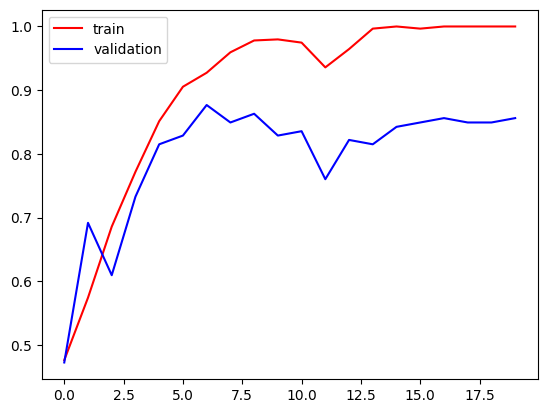

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

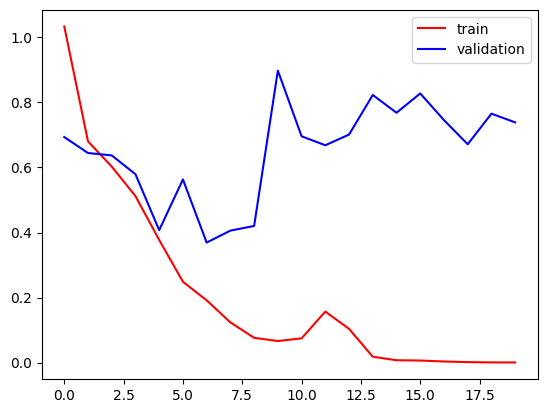

In [40]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [41]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 738 images belonging to 2 classes.


In [42]:
#predict the test data
predictions = model.predict(test_data)


24/24 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step


In [43]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[213 176]
 [183 166]]
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.55      0.54       389
           1       0.49      0.48      0.48       349

    accuracy                           0.51       738
   macro avg       0.51      0.51      0.51       738
weighted avg       0.51      0.51      0.51       738



There is overfitting and hence applying Batchnormalisation and Dropout techniques to handle overfitting

In [47]:
# create CNN model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid',
                 activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))


model.add(Dense(1, activation='sigmoid'))

In [48]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [49]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 496ms/step - accuracy: 0.7652 - loss: 5.8305 - val_accuracy: 0.5274 - val_loss: 6.6112
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.8632 - loss: 3.3649 - val_accuracy: 0.5274 - val_loss: 14.7328
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.9139 - loss: 1.4998 - val_accuracy: 0.5685 - val_loss: 1.4359
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.9257 - loss: 1.1865 - val_accuracy: 0.6164 - val_loss: 2.5772
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 306ms/step - accuracy: 0.9274 - loss: 0.8671 - val_accuracy: 0.5274 - val_loss: 7.7272
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - accuracy: 0.9544 - loss: 0.5910 - val_accuracy: 0.5548 - val_loss: 4.7020
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.9493 - loss: 0.9173 - val_accuracy: 0.6575 - val_loss: 5.6703
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 312ms/step - accuracy: 0.9392 - loss: 0.9795 - val_accuracy: 

In [52]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 738 images belonging to 2 classes.


In [51]:
predictions = model.predict(test_data)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step


In [53]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[125 264]
 [104 245]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.55      0.32      0.40       389
           1       0.48      0.70      0.57       349

    accuracy                           0.50       738
   macro avg       0.51      0.51      0.49       738
weighted avg       0.52      0.50      0.48       738



Using Pre-trained model (Transfer learning) - Resnet50  -- 50 Convolutional layers + fully connected layer





In [54]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Dropout


pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(256,256,3),
    pooling='max',
    weights='imagenet'
)


for layer in pretrained_model.layers:
    layer.trainable = False


resnet_model = Sequential()

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())

resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dropout(0.3))


resnet_model.add(Dense(1, activation='sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [56]:
history = resnet_model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 997ms/step - accuracy: 0.5591 - loss: 1.9690 - val_accuracy: 0.5822 - val_loss: 0.6807
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.5980 - loss: 0.8048 - val_accuracy: 0.6164 - val_loss: 0.6265
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.6368 - loss: 0.6796 - val_accuracy: 0.6644 - val_loss: 0.6052
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.6402 - loss: 0.6278 - val_accuracy: 0.6096 - val_loss: 0.6537
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.6419 - loss: 0.6236 - val_accuracy: 0.7260 - val_loss: 0.6041
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.6943 - loss: 0.5804 - val_accuracy: 0.6781 - val_loss: 0.5835
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.6875 - loss: 0.5897 - val_accuracy: 0.7192 - val_loss: 0.5806
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.6622 - loss: 0.6541 - val_accuracy: 0

In [57]:
predictions = resnet_model.predict(test_data)

24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 376ms/step


In [58]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[103 286]
 [ 89 260]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.54      0.26      0.35       389
           1       0.48      0.74      0.58       349

    accuracy                           0.49       738
   macro avg       0.51      0.50      0.47       738
weighted avg       0.51      0.49      0.46       738

